In [96]:
import warnings

warnings.filterwarnings("ignore")

In [97]:
import tensorflow as tf

In [98]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../Data/catVdog/animals/Train",
    image_size=(64, 64),
    batch_size=32,
    seed=42
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../Data/catVdog/animals/Test",
    image_size=(64, 64),
    batch_size=32,
    seed=42
)

Found 800 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


In [99]:
classes = train_dataset.class_names
classes

['cat', 'dog']

image shape -> (32, 64, 64, 3)


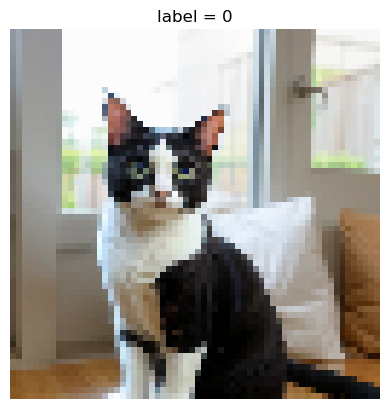

In [100]:
import matplotlib.pyplot as plt

image, label = next(iter(train_dataset))
print(f"image shape -> {image.shape}")
img = image[1] / 255.0

plt.imshow(img)
plt.axis("off")
plt.title(f"label = {label[1]}")
plt.show()

In [101]:
from tensorflow.keras.models import Sequential

data_augment = Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomHue(factor=0.2),
    tf.keras.layers.RandomRotation(factor=0.8)
])

In [102]:
train_dataset = train_dataset.map(lambda x, y : (data_augment(x), y))

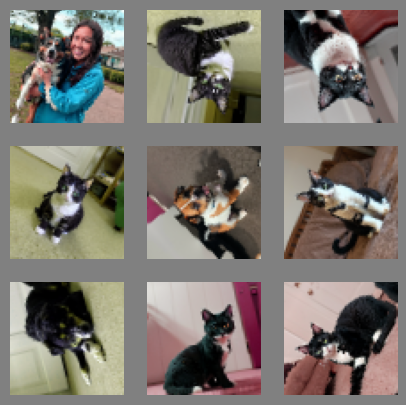

In [105]:
for Image, Label in train_dataset.take(1):
    fig = plt.figure(figsize=(5,5), facecolor="grey")
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        ax.imshow(Image[i] / 255.0)
        ax.axis("off")

In [106]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Rescaling

model = Sequential()
model.add(Rescaling(1./255, input_shape=(64, 64, 3)))
model.add(Conv2D(16, 3, activation="relu"))
model.add(MaxPooling2D())
model.add(Conv2D(32, 3, activation="relu"))
model.add(MaxPooling2D())
model.add(Conv2D(64, 3, activation="relu"))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [107]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [108]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)              │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 318,753 (1.22 MB)

 Trainable params: 318,753 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
history = model.fit(train_dataset, epochs=10, validation_data=test_dataset)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.5437 - loss: 0.6890 - val_accuracy: 0.6350 - val_loss: 0.6591
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.6175 - loss: 0.6607 - val_accuracy: 0.6550 - val_loss: 0.6053
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.7125 - loss: 0.5602 - val_accuracy: 0.8050 - val_loss: 0.4880
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.7450 - loss: 0.5045 - val_accuracy: 0.8150 - val_loss: 0.4246
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.7775 - loss: 0.4598 - val_accuracy: 0.7950 - val_loss: 0.4472
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8662 - loss: 0.3583 - val_accuracy: 0.7950 - val_loss: 0.4245
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.8400 - loss: 0.3457 - val_accuracy: 0.8750 - val_loss: 0.3304
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.8662 - loss: 0.3229 - val_accuracy: 0.

In [110]:
IMAGE, LABEL = next(iter(test_dataset))

In [117]:
IMAGE[30].shape

TensorShape([64, 64, 3])

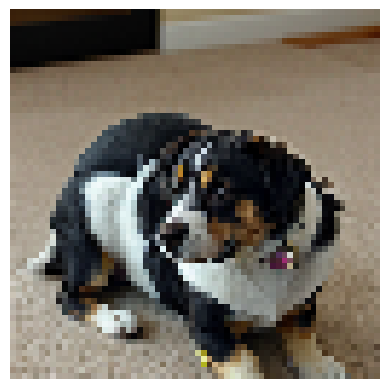

In [118]:
plt.imshow(IMAGE[30] / 255.0)
plt.axis("off")
plt.show()

In [119]:
processed_image =  data_augment(tf.expand_dims(IMAGE[30], axis=0))

In [120]:
prediction = model.predict(processed_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [125]:
["Dog" if prediction > 0.5 else "Cat"]

['Dog']